# Clustering and k-means
🟠 🟡 🟢 🟣 🟤 🔵 🔴


So far, most of our models have been **supervised**: the data came with an answer 🏷️
(a label or a number) and the model learned to predict it. **Clustering** is different.
It is **unsupervised** - there are *no labels*. We simply hand the algorithm a pile of
data points and ask: *"Which of these belong together?"*

The algorithm groups the points into **clusters**, so that data points in the same cluster are
similar to each other, and data points in different clusters are less similar.

Why is this useful in materials science?

- Grouping materials into **families** by their properties or composition, without deciding
  the families in advance.
- Splitting a **micrograph** into its different phases or grains.
- Finding distinct patterns in a large batch of **spectra** (XRD, Raman, EDS).

In this page we focus on the most widely used clustering method, **k-means**.

:::{dropdown} 🔑 Words to listen for
- **Unsupervised learning** - learning from data that has *no* labels.
- **Cluster** - a group of points that are similar to one another.
- **Centroid** - the centre of a cluster; the *mean* position of its points.
- **Inertia (WCSS)** - the total squared distance from points to their cluster centre. Smaller = tighter clusters.
- **k** - the number of clusters we ask for (we must choose it).
- **Silhouette** - a score (−1 to 1) for how well a point fits its cluster.
:::

## k-means clustering

The core idea is a simple two-step loop, repeated until nothing changes:

1. **Assign** - put each point in the cluster whose centre (centroid) is nearest. 🎯
2. **Update** - move each centroid to the **mean** of the points assigned to it. 🔄

:::{tip} Watch it happen first
Step through the algorithm one point at a time in **⏯️ [the interactive animation](data/kmeans.html)** and see how it assigns each data point to clusters.
    
:::

What is k-means actually trying to do? It searches for centroids that make the clusters as
**tight** as possible. "Tightness" is measured by the **inertia** (also called the
within-cluster sum of squares, WCSS):

$$\text{inertia} \;=\; \sum_{j=1}^{k}\ \sum_{x \in C_j} \lVert x - \mu_j \rVert^{2}$$

where $C_j$ is cluster $j$ and $\mu_j$ is its centroid. Each full loop can only make the
inertia smaller or leave it the same, so the algorithm always settles down (converges).

# In-class Problem

We will walk through the simple clustering example worked out in-class. You can refer to the lecture recording on Canvas for guidance.

📊[Conductivity Dataset for Clustering](data/lec04-Kmeans.csv)

- Sample number (unique identifier)
- Electrical Conductivity $(\times 10^7 S/m)$
- Thermal Conductivity $(W/mK)$

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"   # The OS package environment was set in response to a warning that occured 
                                    # during the code. It is safe to ignore such Warnings in codes. 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [2]:
data = pd.read_csv("data/lec04-Kmeans.csv")   # Replace the dataset name and path 
data.head()

,Sample number,Thermal Conductivity,Electrical Conductivity
0,1,164.0,3.030
1,2,164.0,3.448
2,3,70.0,4.545
3,4,190.0,2.857
4,5,190.0,2.778


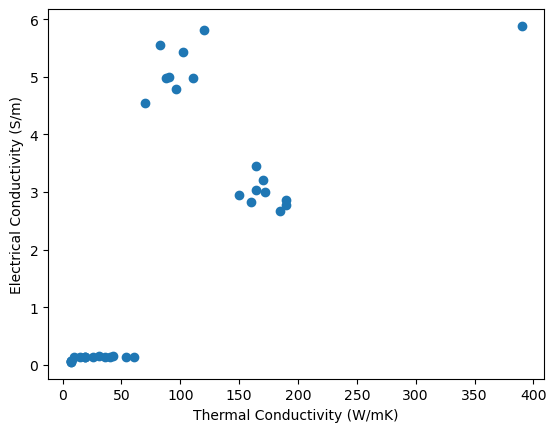

In [3]:
plt.scatter(data['Thermal Conductivity'],data['Electrical Conductivity']) 
plt.xlabel("Thermal Conductivity (W/mK)")
plt.ylabel("Electrical Conductivity (S/m)")
plt.show()

In [4]:
#k=4  by visual inspection

kmeans = KMeans(n_clusters=4,n_init=10)    #Instantiating the KMeans model
kmeans.fit(data)
## In this case data is two-D, so kmeans considers both datapoints (x,y) and computes the Euclidean distance to the centroid. 
#If the data was 3-D, then it will take (x,y,z) and still compute the Euclidean distance based on the number of dimensions.

,n_clusters,4
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


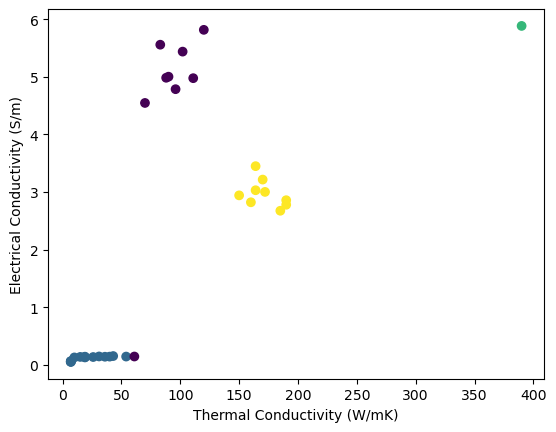

In [5]:
plt.scatter(data['Thermal Conductivity'],data['Electrical Conductivity'],c=kmeans.labels_)
plt.xlabel("Thermal Conductivity (W/mK)")
plt.ylabel("Electrical Conductivity (S/m)")
plt.show()

In [6]:
print(kmeans.labels_)  
#Each datapoint is assigned to a cluster number - 0,1,2,3 : 4 clusters

[3 3 0 3 3 3 3 3 3 3 2 0 0 0 0 0 0 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1]


As can be seen in the graph, there's a datapoint that has been "Misclassified".
This happens because the KMeans algorithm calculates the Eucledian distance between points. 
When the two axes are of different scales, this can cause errors.
The two axes are numbered according to the different units of measurement used, and if we switched to another set of units, the scales would be different - so in a sense this measurement is arbitrary, and not absolute.
Therefore this results in errors.

Which means we need to standardize the axes before running a K-means clustering task.

In [7]:
#Misclassification due to the two axes being on two different scales
#Need to standardize
scaler = MinMaxScaler()
#scaler = StandardScaler()   #Create an instance of the standard scaler   #Z-score, #Standard normal distribution
scaler.fit(data)       #MinMax Scaler


,feature_range,"(0, ...)"
,copy,True
,clip,False


In [8]:
#For Standard Scaler
#print(scaler.mean_)   #Optional - Minmax scaler has no such attribute
#print(scaler.var_)    #Optional

In [9]:
data_trans=scaler.transform(data)     #Applying the above statistics to transform/standardize the data
#print(data_trans)

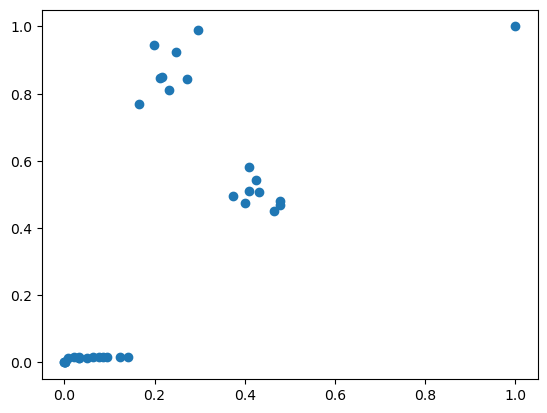

In [10]:
plt.scatter(data_trans[:,1],data_trans[:,2]) #Just plotting the un-clustered data to check the rescaling 
plt.show()

In [11]:
kmeans_std = KMeans(n_clusters=4,n_init=10) #init='random','k-means++' by default its kmeans++
#Instantiate a new KMeans object for standardized data
kmeans_std.fit(data_trans)

,n_clusters,4
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


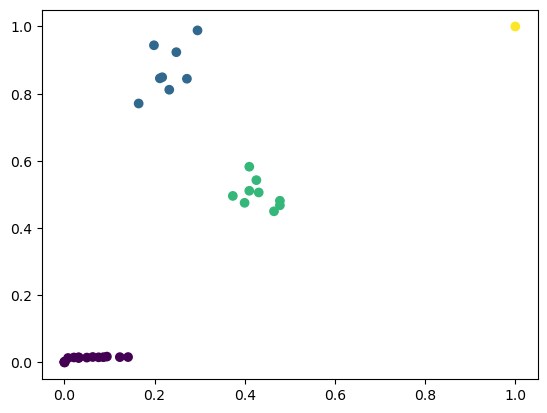

In [12]:
plt.scatter(data_trans[:,1],data_trans[:,2],c=kmeans_std.labels_)
plt.show()

In [13]:
print(f'final inertia of the selected centroids are: {kmeans_std.inertia_}')


final inertia of the selected centroids are: 0.6588779931191605


In this example, we started by selecting the number of clusters as 4.
But in a real world problem, we might not even know how many clusters there should be.
In certain cases, we would be dealing with high-dimensional data (more than 3-D) in which case we cannot plot - or visualize them - and therefore we cannot say how many clusters there are.

So, in such cases we want the algorithm to try out several different numbers of clusters (n=1,2,3,...) and calculate the 'inertia' or inter-cluster variance, so we can then decide which clustering number (k) works best.

In [14]:
#KMeans package : variance is termed inertia

clusters=[]    #Initialize an empty array to store the inertia/variance values

for i in range(1,11):
    km = KMeans(n_clusters=i,n_init=10)
    km.fit(data_trans)
    clusters.append(km.inertia_)

#For integers 1 - 10, kmeans clustering is carried out, the variance
#is calculated and we add that value to our array


km.n_iter_   #number of iterations before convergence - this value can change each time.

2

In [15]:
len(clusters)  #decided by the range 

10

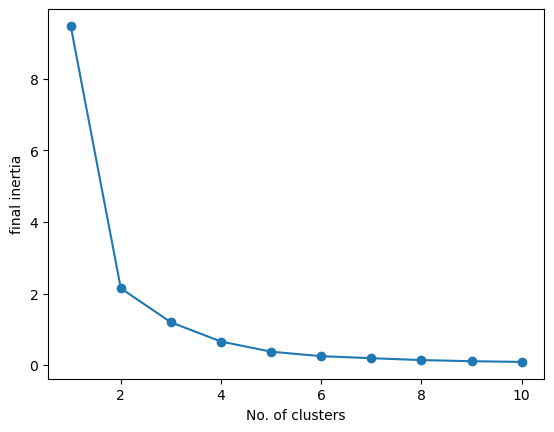

In [16]:
#Let's see how the inertia changes with the number of clusters -k
plt.plot(range(1,11),clusters,marker='o')
plt.xlabel("No. of clusters")
plt.ylabel("final inertia")
plt.show()


The inertia will keep decreasing until $k = $ number of clusters (each datapoint will be a cluster by itself)
Surely, this is not right! 

There has to be an "optimum" number of clusters that's not too little and not too many.
That is found at the 'elbow' point of the above graph.

# Clustering is an Un-supervised technique

We are not dealing with labeled data.
🔌We started with a dataset that listed some materials samples with their electrical and thermal conductivities. We didn't know what the relationships between them are - and we don't even know what categories they fall into.

But through clustering - we can see that there can be a few different types (4 in this example) of materials based on conductivity measurements. 

🟡 High thermal + high electrical (the outlier, and loosely the trend line toward it): classic metals - copper, silver, gold, aluminum. Free electrons dominate both properties, so they move together.

🔵Low thermal + low electrical (bottom-left, tightly-packed cluster): electrical and thermal insulators - polymers, wood, most ceramics without special phonon engineering. Neither electrons nor phonons move heat/charge efficiently.

🟢 🟣The two "middle" clusters (moderate thermal ~70-190, moderate electrical) are the more interesting ones: their thermal conductivity is noticeably higher (than predicted by Wiedemann-Franz law alone). It means an additional, non-electronic heat-carrying mechanism (lattice vibrations, i.e. phonons) is contributing on top of whatever the electrons are doing. This is exactly the physics behind materials like doped semiconductors, graphite/graphene-based composites, and some alloys, where phonon transport can partially "decouple" thermal conductivity from electrical conductivity - which is also the whole design principle behind thermoelectric materials (which try to do the opposite: maximize this decoupling for efficiency).


## Another example

Let's add in some more depth to clustering.

Below is some unlabelled data - think of each point as a material described by two measured
properties (**Feature 1** and **Feature 2**). No colours, no labels. Your eye already sees
groups; clustering is how we teach a computer to find them.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.ndimage import gaussian_filter

# a small colour palette for clusters
PAL = ["#e4572e", "#2e6fdb", "#2ea44f", "#f5a623", "#8e44ad", "#00b3b3"]

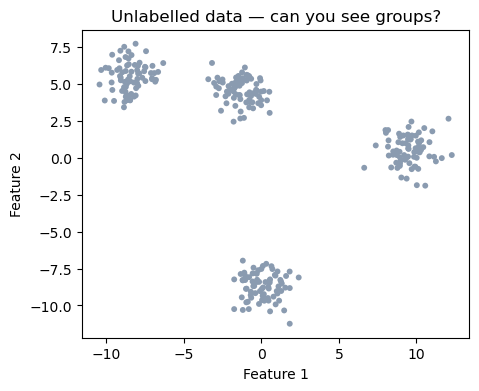

In [18]:
# Constructed data: 4 natural groups (we pretend we don't know that yet)
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.95, random_state=7)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(X[:, 0], X[:, 1], s=18, color="#8a9bb0", edgecolors="none")
ax.set_title("Unlabelled data — can you see groups?")
ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")
plt.show()

What is K?

In the above graph, how many clusters do you see?

Answer: 4 $\rightarrow$ k=4

So k-means clustering should be 4-means clustering in this example.

### Choosing the starting seeds

k-means has to start from *somewhere* - it needs initial centres. This choice matters,
because k-means only finds a **local** best answer that depends on where it started.

- **Random / Forgy** - pick *k* actual data points at random as the first centres.
  This is what the animation does. Simple, but two centres can land in the same group and
  give a poor result.
- **Random partition** - randomly assign every point to a cluster first, then compute centres.
- **k-means++** - a smarter start that **spreads the centres out**: pick the first centre at
  random, then pick each next centre from the data with a chance proportional to its squared
  distance from the nearest centre already chosen. This way the algorithm is encouraged to pick the second centroid further away from the first one. This avoids clumped starts and usually
  converges faster to a better answer. **scikit-learn uses k-means++ by default.** 
- **Multiple restarts (`n_init`)** - run the whole thing several times from different starts
  and keep the result with the **lowest inertia**. scikit-learn does this automatically.

Let's see why restarts matter. We run k-means many times with a *single* random start, and
watch the final inertia jump around:

In [19]:
# Same data, k=4, but with a single random start each time (init="random", n_init=1)
single_start = []
for seed in range(8):
    km = KMeans(n_clusters=4, init="random", n_init=1, random_state=seed).fit(X)
    single_start.append(round(km.inertia_, 1))

# k-means++ with several restarts (scikit-learn's default behaviour)
best = KMeans(n_clusters=4, init="k-means++", n_init=10, random_state=0).fit(X)

print("Inertia from 8 single random starts:", single_start)
print("Inertia from k-means++ (best of 10):", round(best.inertia_, 1))

Inertia from 8 single random starts: [2401.8, 515.6, 2404.7, 515.6, 2403.6, 2409.2, 6992.6, 515.6]
Inertia from k-means++ (best of 10): 515.6


Notice how some single starts land on a good answer while others get stuck on a much
worse one - the inertia is sometimes several times larger. **k-means++ with a few restarts**
reliably finds the good (low-inertia) solution. In practice, just let scikit-learn handle this;
the defaults already do the right thing.

### How many clusters? 🤔 Choosing *k* 

k-means needs you to pick *k* **before** it runs. But how do you know the right number?
Two common tools help.

**The elbow method.** Run k-means for a range of *k* and plot the inertia. Inertia always
falls as *k* grows (more centres always fit tighter - at $k = N$ every point is its own
cluster and inertia is 0). So we don't pick the minimum. Instead we look for the **elbow**:
the point where adding more clusters stops buying much improvement.

**The silhouette method.** For each point, compare how close it is to its **own** cluster
($a$) versus the **nearest other** cluster ($b$). The silhouette value is $(b - a)/\max(a, b)$,
ranging from $-1$ (wrong cluster) to $+1$ (well inside its cluster). Average this over all
points and pick the *k* with the **highest** score.

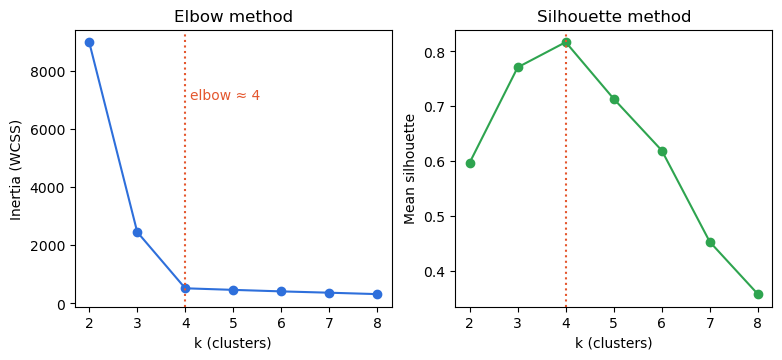

Highest silhouette at k = 4


In [20]:
ks = range(2, 9)
inertias, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.6))
ax1.plot(list(ks), inertias, "o-", color="#2e6fdb")
ax1.axvline(4, ls=":", color="#e4572e"); ax1.text(4.1, max(inertias)*0.78, "elbow \u2248 4", color="#e4572e")
ax1.set_title("Elbow method"); ax1.set_xlabel("k (clusters)"); ax1.set_ylabel("Inertia (WCSS)")

best_k = list(ks)[int(np.argmax(silhouettes))]
ax2.plot(list(ks), silhouettes, "o-", color="#2ea44f")
ax2.axvline(best_k, ls=":", color="#e4572e")
ax2.set_title("Silhouette method"); ax2.set_xlabel("k (clusters)"); ax2.set_ylabel("Mean silhouette")
plt.show()

print("Highest silhouette at k =", best_k)

Both point to the same answer: the elbow bends at **k = 4**, and the silhouette score
**peaks at k = 4**. That matches what our eyes saw at the start.

Other tools exist too - the **gap statistic**, the **Davies–Bouldin** and
**Calinski–Harabasz** indices - but the single most important guide is often **domain
knowledge**: if you know a sample should contain three phases, that is strong evidence for
*k = 3*. These methods **support** your judgement; they don't replace it.

Here is the final clustering with *k = 4* (centres shown as ✕):

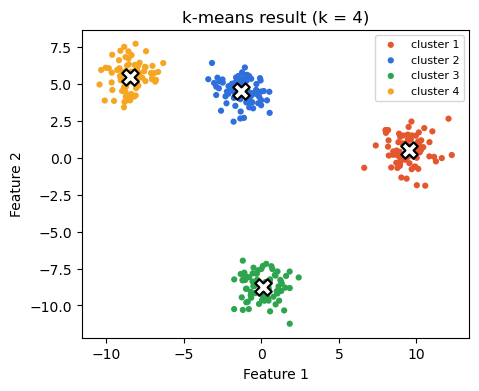

In [21]:
km = KMeans(n_clusters=4, n_init=10, random_state=0).fit(X)

fig, ax = plt.subplots(figsize=(5, 4))
for c in range(4):
    m = km.labels_ == c
    ax.scatter(X[m, 0], X[m, 1], s=20, color=PAL[c], edgecolors="none", label=f"cluster {c+1}")
ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
           marker="X", s=140, c="white", edgecolors="black", linewidths=1.6, zorder=5)
ax.set_title("k-means result (k = 4)")
ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2"); ax.legend(fontsize=8)
plt.show()

## Advantages and limitations

**Advantages**

- **Simple and fast**, and scales well to large datasets.
- **Easy to interpret** - each cluster is summarised by its centre.
- Works well when clusters are roughly **round, similar in size, and well separated**.

**Limitations**

- You must **choose *k*** in advance.
- **Sensitive to the starting seeds** (local optima) - use k-means++ and several restarts.
- Assumes **round, similar-sized** clusters. It struggles with elongated or curved shapes.
- **Sensitive to feature scale** - a feature with large numbers can dominate the distance,
  so **standardise** your features first (e.g. `StandardScaler`).
- **Sensitive to outliers**, which drag centroids toward themselves.
- **Hard assignment** - every point is forced into exactly one cluster, with no measure of
  confidence. (GMM gives soft, probabilistic memberships instead.)



## Other clustering algorithms

k-means is not the only option. It helps to know the main families, because each makes
different assumptions about what a "cluster" looks like:

- **k-means (centroid-based)** - groups points around *k* centres. Fast and simple; likes
  round, similar-sized clusters.
- **Hierarchical / agglomerative** - repeatedly merges the closest points/groups, building a
  tree (a *dendrogram*). You don't need to fix *k* up front; you cut the tree where you like.(Imagine how animal species can be arranged based on their evolutionary pathways)  
- **DBSCAN (density-based)** - grows clusters through dense regions. It finds **arbitrary
  shapes**, decides the number of clusters itself, and labels sparse points as **noise**. (Imagine a map of a country by population - you will see a higher density of people in big cities, then smaller towns and sparse data in between)
- **Gaussian Mixture Models (GMM)** - like a "soft" k-means: each point gets a *probability*
  of belonging to each cluster, and clusters can be stretched ellipses.
- **Spectral / mean-shift** -other approaches useful for tricky, non-round shapes.

:::{note}
There is no single "best" algorithm. The right choice depends on the **shape** of your
clusters and whether you know **how many** to expect.
:::

The shape limitation is easy to see. Below, the data forms two interleaving crescents.
k-means can only cut a straight boundary, so it splits them wrongly - while **DBSCAN**,
which follows dense regions, recovers the two shapes.

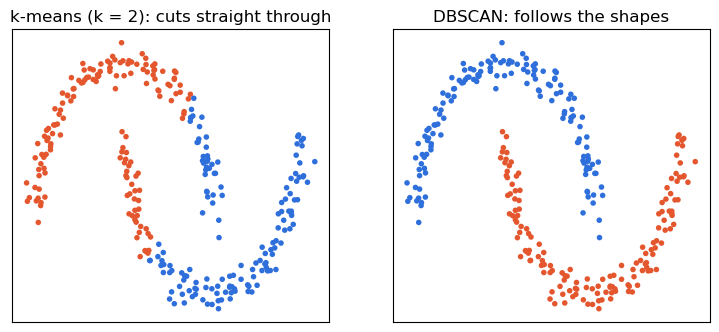

In [22]:
Xm, _ = make_moons(n_samples=300, noise=0.06, random_state=0)
km_m = KMeans(n_clusters=2, n_init=10, random_state=0).fit(Xm)
db_m = DBSCAN(eps=0.2, min_samples=5).fit(Xm)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.8))
for c in np.unique(km_m.labels_):
    m = km_m.labels_ == c
    ax1.scatter(Xm[m, 0], Xm[m, 1], s=16, color=PAL[c % len(PAL)], edgecolors="none")
ax1.set_title("k-means (k = 2): cuts straight through")

for c in np.unique(db_m.labels_):
    m = db_m.labels_ == c
    col = "#b9c4d1" if c == -1 else PAL[c % len(PAL)]   # grey = noise
    ax2.scatter(Xm[m, 0], Xm[m, 1], s=16, color=col, edgecolors="none")
ax2.set_title("DBSCAN: follows the shapes")

for a in (ax1, ax2):
    a.set_xticks([]); a.set_yticks([])
plt.show()

## Image segmentation with k-means 🖼️

😎 Here is a cool use of k-means. If you take an image, it is just a grid of pixels, and each pixel has a
**colour** (or, for a grayscale image, a single **brightness** value). If we treat every
pixel as a **data point** living in colour space, we can cluster the pixels into *k* groups.
Each group becomes a region of similar colour - a **segment**. (Replacing every pixel by its
cluster colour is also known as *colour quantization*.)

This is directly useful in materials science. A **micrograph** often shows a few **phases**
with different brightness. Clustering the pixel intensities into *k* groups separates the
image into those phases.

Below we build a **synthetic** noisy micrograph with three phases, then let k-means recover
them from the pixel brightness alone.

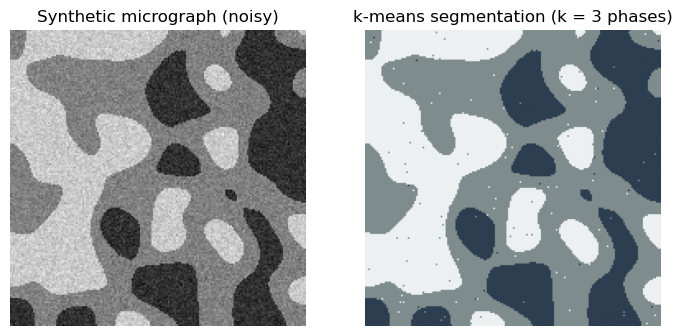

Area fraction of each phase (dark, mid, light): [0.245, 0.459, 0.296]


In [23]:
def make_microstructure(n=180, seed=3):
    # Constructed grayscale 'micrograph' with three phases + noise.
    rng = np.random.default_rng(seed)
    field = gaussian_filter(rng.standard_normal((n, n)), sigma=10)     # smooth blobs
    field = (field - field.min()) / (field.max() - field.min())
    phase = np.digitize(field, [0.40, 0.62])                          # -> 0, 1, 2
    base = np.array([70, 140, 205])[phase].astype(float)             # 3 brightness levels
    return np.clip(base + rng.normal(0, 12, (n, n)), 0, 255)         # add noise

img = make_microstructure()

# treat each pixel (its brightness) as a data point, cluster into 3 phases
pixels = img.reshape(-1, 1)
seg_km = KMeans(n_clusters=3, n_init=10, random_state=0).fit(pixels)

# relabel clusters by brightness so colours are consistent (dark -> light)
order = np.argsort(seg_km.cluster_centers_.ravel())
remap = np.empty_like(order); remap[order] = np.arange(3)
segmented = remap[seg_km.labels_].reshape(img.shape)

from matplotlib.colors import ListedColormap
cmap = ListedColormap(["#2c3e50", "#7f8c8d", "#ecf0f1"])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.4, 4.2))
ax1.imshow(img, cmap="gray"); ax1.set_title("Synthetic micrograph (noisy)"); ax1.axis("off")
ax2.imshow(segmented, cmap=cmap); ax2.set_title("k-means segmentation (k = 3 phases)"); ax2.axis("off")
plt.show()

fractions = [round(float((segmented == i).mean()), 3) for i in range(3)]
print("Area fraction of each phase (dark, mid, light):", fractions)

From noisy pixels, k-means cleanly separates the three phases, and we can even read off
each phase's **area fraction** - a quantity materials scientists care about.

A few practical notes:
- For a **colour** image, use the three channels (R, G, B) as the features instead of one
  brightness value.
- To make segments more **spatially compact**, add each pixel's position $(x, y)$ as extra
  features (after scaling), so nearby pixels tend to group together.
- k-means is a fast **baseline**. Real micrographs with gradients or textures often need more
  careful methods, but k-means is an excellent first tool.

## Other applications in materials science

Clustering shows up all over the field:

- **Phase and grain segmentation** of micrographs, EBSD maps, and EDS/hyperspectral images
  (as above).
- **Grouping compounds into families** by composition or descriptor vectors (for example,
  features from Matminer) to explore a dataset or pick a **diverse** set of candidates.
- **Sorting spectra** (XRD, Raman, XPS) in high-throughput experiments to find how many
  distinct patterns are present.
- **Compressing large datasets** by keeping one representative per cluster - handy for
  choosing which structures to run expensive **DFT** calculations on.
- **Grouping local atomic environments** or structural motifs in simulations.
- **Spotting anomalies**: a point far from *every* centroid may be an unusual material worth
  a closer look.
- **Bootstrapping labels for supervised learning**: cluster first, then have an expert confirm or name just a few representatives per cluster - turning an expensive full-dataset labeling job into training data for a classifier.

And well beyond materials, the same idea powers image colour compression, document/topic
grouping, and customer segmentation.

## Key takeaways 🎯

- **Clustering is unsupervised**: it finds groups in data that has no labels.
- **k-means** repeats two steps - assign points to the nearest centre, then move each centre
  to its cluster's mean - until nothing changes.
- It minimises **inertia** (within-cluster spread) but only finds a **local** optimum, so use
  **k-means++** and **several restarts**.
- Choose *k* with the **elbow** and **silhouette** methods, guided by **domain knowledge**.
- k-means is fast and simple but assumes **round, similar-sized** clusters and needs
  **scaled** features.
- Treating pixels as points makes k-means a quick tool for **image / phase segmentation**.

:::{dropdown} ✅ Check your understanding
**1. Inertia always drops as *k* increases. So why not just pick the *k* with the smallest inertia?**
Because more centres can always fit the data more tightly - at $k = N$ every point is its own
cluster and inertia is 0 (This is over-fitting!). That would give many meaningless clusters. Use the *elbow*,
*silhouette*, and domain knowledge instead.

**2. Your k-means result looks different each time you run it. Why, and how do you get a stable answer?**
k-means converges to a *local* optimum that depends on the random starting centres. Use
**k-means++** initialisation with several restarts (`n_init`) and keep the lowest-inertia result.

**3. You cluster materials using "hardness (GPa)" and "density (kg/m³)". Why might density dominate the result?**
Density values are numerically far larger, and k-means measures distance with those raw
numbers, so the large-magnitude feature dominates. **Standardise** the features first so each
contributes fairly.
:::

# 

# ☕ Home Work Practice

Download this [dataset](data/lec04-materials_clustering.csv) and this [jupyter notebook file](data/lec04-HW_kmeans_materials_classes.ipynb) and save it in your environment folder.

You can follow the instructions given in the notebook and fill in the codes - while analysing the outputs. 

Fix errors if they arise, and try and understand the problem and guided exercise.

The solutions will be uploaded later for you to self-refer.


# ☕ Home Work Practice (Curve-fitting Advanced)

You can download this [atomic radii dataset](data/lec04-atomic_radii_dataset.csv), and download this [worked out jupyter notebook](Week04-5_HW_Atomic_radii.ipynb) and simply run the cells while working your way through it.

The worked out solutions are in the following page.

